In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch



file = Path("Time_Trace_3324.bin")  

with open(file, "rb") as f:
    rows_i, cols_i = np.fromfile(f, dtype=">u4", count=2)
    data_i = np.fromfile(f, dtype=">f8")

arr_i = data_i.reshape((rows_i, cols_i))[:-1, :]

time = arr_i[:, 0]
pixels_V = arr_i[:, 1:]   # voltage traces, one column per pixel

print("File:", file)
print("Rows:", rows_i)
print("Columns:", cols_i)
print("Used samples:", len(time))
print("Number of pixels:", pixels_V.shape[1])

File: Time_Trace_3324.bin
Rows: 46869
Columns: 50
Used samples: 46868
Number of pixels: 49


In [2]:
#sampling f and bandwidth

dt = np.mean(np.diff(time))
fs = 1 / dt

N = len(time)
total_time = N * dt

df = fs / N
bandwidth = fs / 2

print(f"dt = {dt:.6e} s")
print(f"fs = {fs:.6f} Hz")
print(f"N = {N}")
print(f"Total time = {total_time:.6f} s")
print(f"Frequency spacing df = fs/N = {df:.6f} Hz")
print(f"Measurement bandwidth = Nyquist frequency = fs/2 = {bandwidth:.6f} Hz")

dt = 2.160000e-05 s
fs = 46296.296296 Hz
N = 46868
Total time = 1.012349 s
Frequency spacing df = fs/N = 0.987802 Hz
Measurement bandwidth = Nyquist frequency = fs/2 = 23148.148148 Hz


In [3]:
pixels_V_zero_mean = pixels_V - np.mean(pixels_V, axis=0) #subtract mean, fft it

segment_length_s = 2

nperseg = int(segment_length_s * fs)
nperseg = min(nperseg, N)
noverlap = nperseg // 2

freqs, PSD_V = welch(
    pixels_V_zero_mean,
    fs=fs,
    window="hann",
    nperseg=nperseg,
    noverlap=noverlap,
    detrend=False,
    return_onesided=True,
    scaling="density",
    axis=0
)

df_welch = freqs[1] - freqs[0]


In [4]:
ASD_V = np.sqrt(PSD_V)#  V/sqrt(Hz)

slope_dV_df = 5e-8
gamma_e = 28.02495164e9

slope_dV_dB = slope_dV_df * gamma_e #V/Hz

ASD_B_T = ASD_V / slope_dV_dB
ASD_B_nT = ASD_B_T * 1e9


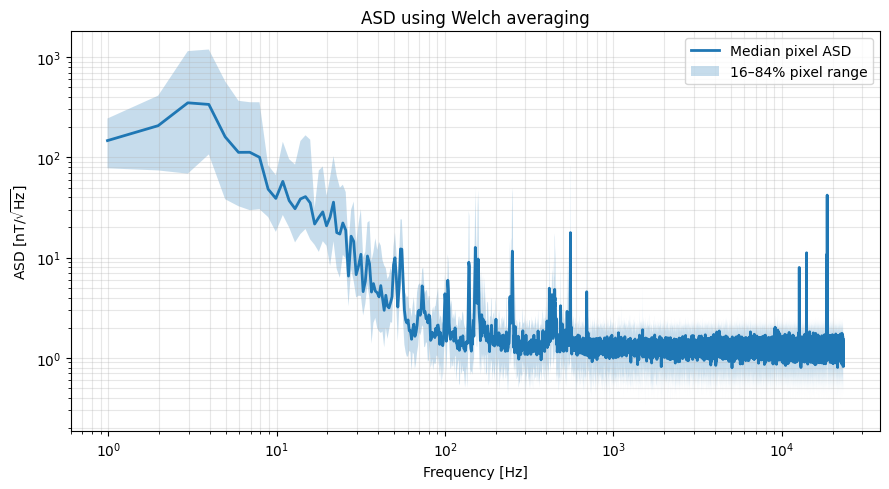

In [5]:
ASD_median = np.median(ASD_B_nT, axis=1)
ASD_16 = np.percentile(ASD_B_nT, 16, axis=1)
ASD_84 = np.percentile(ASD_B_nT, 84, axis=1)

plt.figure(figsize=(9, 5))

plt.loglog(freqs[1:], ASD_median[1:], linewidth=2, label="Median pixel ASD")

plt.fill_between(
    freqs[1:],
    ASD_16[1:],
    ASD_84[1:],
    alpha=0.25,
    label="16–84% pixel range"
)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [nT/$\sqrt{\mathrm{Hz}}$]")
plt.title("ASD using Welch averaging")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# ------------------------------------------------------------
# 8. Try several sensitivity bands
# ------------------------------------------------------------

candidate_bands = [
    (100, 500),
    (300, 1000),
    (500, 3000),
    (1000, 5000),
    (300, 3000),
    (1000, 7000),
]

print("Candidate sensitivity bands")
print("---------------------------")

for fmin, fmax in candidate_bands:
    band = (freqs >= fmin) & (freqs <= fmax)

    eta_pixels = np.median(ASD_B_nT[band, :], axis=0)

    eta_med = np.median(eta_pixels)
    eta_16 = np.percentile(eta_pixels, 16)
    eta_84 = np.percentile(eta_pixels, 84)

    print(f"{fmin:5.0f}–{fmax:<5.0f} Hz : "
          f"{eta_med:8.4g} nT/sqrt(Hz) "
          f"({eta_med*1000:8.4g} pT/sqrt(Hz)), "
          f"16–84%: {eta_16:.4g}–{eta_84:.4g}")

Candidate sensitivity bands
---------------------------
  100–500   Hz :    1.503 nT/sqrt(Hz) (    1503 pT/sqrt(Hz)), 16–84%: 1.284–2.108
  300–1000  Hz :    1.338 nT/sqrt(Hz) (    1338 pT/sqrt(Hz)), 16–84%: 1.206–1.619
  500–3000  Hz :    1.265 nT/sqrt(Hz) (    1265 pT/sqrt(Hz)), 16–84%: 1.175–1.396
 1000–5000  Hz :    1.261 nT/sqrt(Hz) (    1261 pT/sqrt(Hz)), 16–84%: 1.176–1.383
  300–3000  Hz :    1.283 nT/sqrt(Hz) (    1283 pT/sqrt(Hz)), 16–84%: 1.18–1.426
 1000–7000  Hz :    1.258 nT/sqrt(Hz) (    1258 pT/sqrt(Hz)), 16–84%: 1.175–1.377


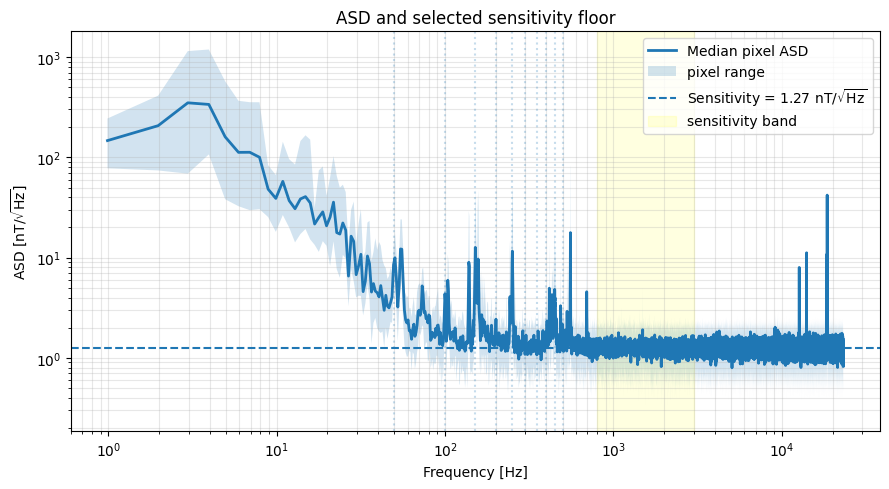

In [7]:
# ------------------------------------------------------------
# 10. Plot ASD with selected sensitivity band
# ------------------------------------------------------------


band = (freqs >= 500) & (freqs <= 3000)

eta_pixels = np.median(ASD_B_nT[band, :], axis=0)

eta_median_nT = np.median(eta_pixels)

plt.figure(figsize=(9, 5))

plt.loglog(freqs[1:], ASD_median[1:], linewidth=2, label="Median pixel ASD")

plt.fill_between(
    freqs[1:],
    ASD_16[1:],
    ASD_84[1:],
    alpha=0.20,
    label="pixel range"
)

plt.axhline(
    eta_median_nT,
    linestyle="--",
    label=rf"Sensitivity = {eta_median_nT:.3g} nT/$\sqrt{{\mathrm{{Hz}}}}$"
)

plt.axvspan(800, 3000, alpha=0.12, color="yellow", label="sensitivity band")

for f0 in [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]:
    if f0 < freqs[-1]:
        plt.axvline(f0, linestyle=":", alpha=0.25)

plt.xlabel("Frequency [Hz]")
plt.ylabel(r"ASD [nT/$\sqrt{\mathrm{Hz}}$]")
plt.title("ASD and selected sensitivity floor")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()